In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))


In [2]:
import pandas as pd
from app.insights.detectors import detect_trends, detect_anomalies, contribution_analysis
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../app/data/raw/sales.csv", parse_dates=["date"])

df.groupby("date", as_index=False)["revenue"].sum().tail()
df.groupby(["date", "category"], as_index=False)["revenue"].sum().head()


,date,category,revenue
0,2024-02-04,Electronics,2025427.52
1,2024-02-04,Fashion,696923.52
2,2024-02-04,Grocery,106208.79
3,2024-02-04,Home,966838.60
4,2024-02-11,Electronics,2137348.91


In [4]:
df.head()

,date,store_id,region,category,subcategory,product_id,price,units,revenue,promo_flag,promo_intensity,stockouts,returns_units,returns_revenue
0,2024-02-04,S001,North,Electronics,Accessories,P1060,754.70,3.77,2846.15,0,0.0,0,0,0.0
1,2024-02-04,S001,North,Electronics,Accessories,P1063,751.31,5.04,3786.96,0,0.0,0,0,0.0
2,2024-02-04,S001,North,Electronics,Accessories,P1066,762.86,3.65,2782.93,0,0.0,0,0,0.0
3,2024-02-04,S001,North,Electronics,Accessories,P1072,303.45,4.01,1218.26,0,0.0,0,0,0.0
4,2024-02-04,S001,North,Electronics,Accessories,P1073,643.09,3.86,2485.48,0,0.0,0,0,0.0


In [5]:
df["date"].min(), df["date"].max()


(Timestamp('2024-02-04 00:00:00'), Timestamp('2026-01-25 00:00:00'))

In [6]:
df["date"].dt.to_period("W").nunique()


104

In [7]:
df.groupby("date")["revenue"].sum().head()


date
2024-02-04    3795398.43
2024-02-11    3973580.80
2024-02-18    3984221.66
2024-02-25    4071138.50
2024-03-03    4351562.93
Name: revenue, dtype: float64

In [8]:
weekly_cat = (
    df.groupby(["date", "category"], as_index=False)["revenue"]
      .sum()
      .sort_values("date")
)


<Axes: xlabel='date', ylabel='revenue'>

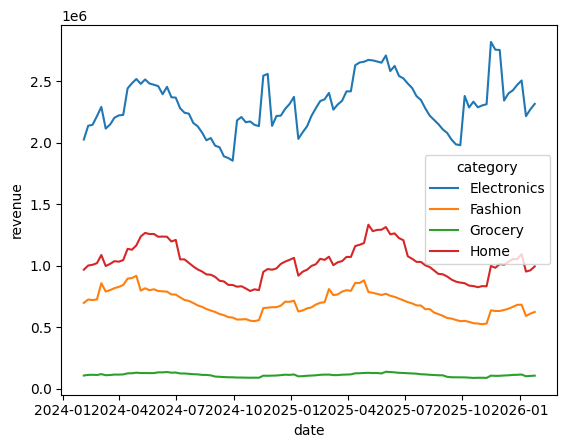

In [9]:
import seaborn as sns
sns.lineplot(data=weekly_cat, x="date", y="revenue", hue="category")


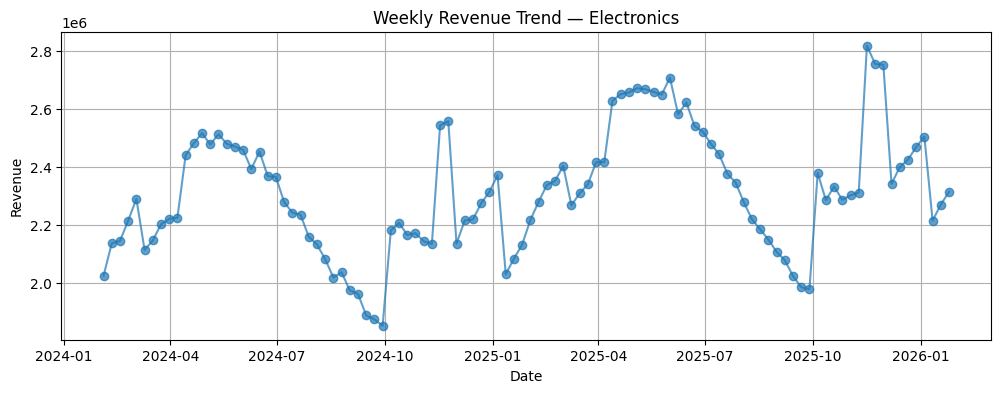

In [10]:
cat_name = "Electronics"

cat_data = weekly_cat[weekly_cat["category"] == cat_name]

plt.figure(figsize=(12,4))
plt.plot(cat_data["date"], cat_data["revenue"], marker="o", alpha=0.7)
plt.title(f"Weekly Revenue Trend — {cat_name}")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()


In [11]:
weekly_cat['category'].unique()

array(['Electronics', 'Fashion', 'Grocery', 'Home'], dtype=object)

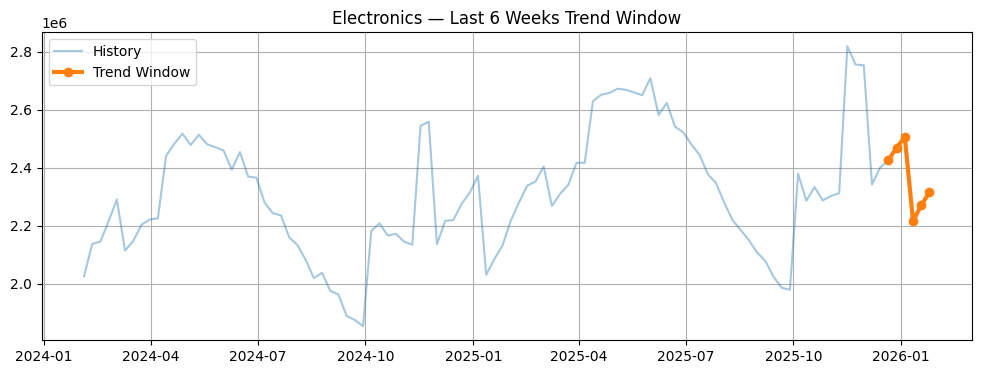

In [12]:
window = 6
recent = cat_data.tail(window)

plt.figure(figsize=(12,4))
plt.plot(cat_data["date"], cat_data["revenue"], alpha=0.4, label="History")
plt.plot(recent["date"], recent["revenue"], marker="o", linewidth=3, label="Trend Window")

plt.title(f"{cat_name} — Last {window} Weeks Trend Window")
plt.legend()
plt.grid(True)
plt.show()


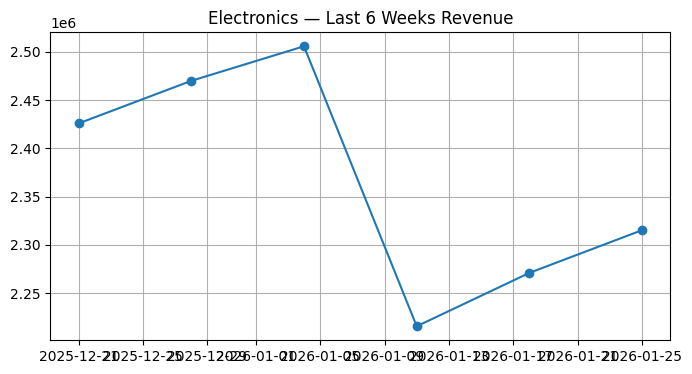

In [13]:
cat = "Electronics"

weekly_cat = (
    df.groupby(["date", "category"], as_index=False)["revenue"]
      .sum()
      .sort_values("date")
)

elec = weekly_cat[weekly_cat["category"] == cat]

recent = elec.tail(6)

plt.figure(figsize=(8,4))
plt.plot(recent["date"], recent["revenue"], marker="o")
plt.title("Electronics — Last 6 Weeks Revenue")
plt.grid(True)
plt.show()


/var/folders/mk/zpbc7y1j0q79v0kw16vsnppw0000gp/T/ipykernel_2348/1126961816.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  elec["rolling_8w"] = elec["revenue"].rolling(8).mean()


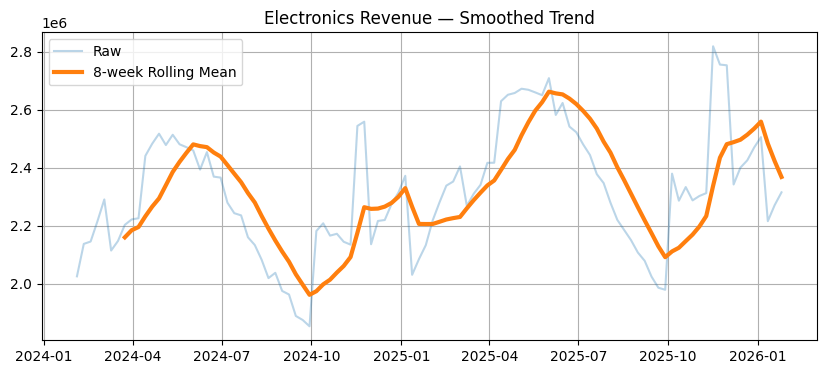

In [14]:
elec["rolling_8w"] = elec["revenue"].rolling(8).mean()

plt.figure(figsize=(10,4))
plt.plot(elec["date"], elec["revenue"], alpha=0.3, label="Raw")
plt.plot(elec["date"], elec["rolling_8w"], linewidth=3, label="8-week Rolling Mean")
plt.legend()
plt.title("Electronics Revenue — Smoothed Trend")
plt.grid(True)
plt.show()


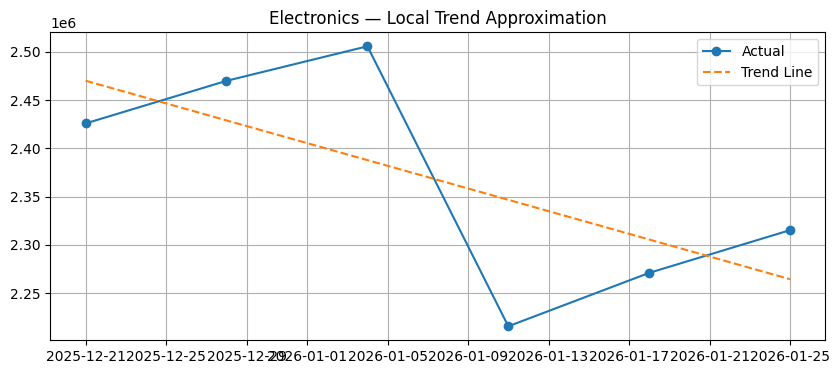

In [15]:
import numpy as np

y = recent["revenue"].values
x = np.arange(len(y))

coef = np.polyfit(x, y, 1)
trend_line = coef[0] * x + coef[1]

plt.figure(figsize=(10,4))
plt.plot(recent["date"], y, marker="o", label="Actual")
plt.plot(recent["date"], trend_line, linestyle="--", label="Trend Line")

plt.title(f"{cat_name} — Local Trend Approximation")
plt.legend()
plt.grid(True)
plt.show()


In [16]:
trends = detect_trends(
    df,
    min_pct_change=0.05,   # 5% instead of 10%
    alpha=0.10             # allow weaker significance
)

anoms = detect_anomalies(df)
contrib = contribution_analysis(df)

print("Trends:", trends[:2])
print("Anomalies:", anoms[:2])
print("Contribution:", contrib[:2])


Trends: [{'type': 'trend', 'metric': 'revenue', 'entity': {'category': 'Electronics'}, 'direction': 'increase', 'pct_change': np.float64(14.31), 'p_value': np.float64(0.0044), 'time_window': '2024-01-29/2024-02-04 → 2026-01-19/2026-01-25'}, {'type': 'trend', 'metric': 'revenue', 'entity': {'category': 'Fashion'}, 'direction': 'decrease', 'pct_change': np.float64(-10.59), 'p_value': np.float64(0.0), 'time_window': '2024-01-29/2024-02-04 → 2026-01-19/2026-01-25'}]
Anomalies: [{'type': 'anomaly', 'metric': 'revenue', 'entity': {'category': 'Electronics'}, 'week': '2024-09-09/2024-09-15', 'value': np.float64(1888655.86), 'z_score': -2.01}, {'type': 'anomaly', 'metric': 'revenue', 'entity': {'category': 'Electronics'}, 'week': '2024-09-16/2024-09-22', 'value': np.float64(1874853.6), 'z_score': -2.08}]
Contribution: [{'type': 'contribution', 'metric': 'revenue', 'entity': {'category': 'Electronics'}, 'week_comparison': '2026-01-12/2026-01-18 → 2026-01-19/2026-01-25', 'delta_value': 44240.51,

In [17]:
for t in trends:
    if t["entity"]["category"] == "Electronics":
        print(t)


{'type': 'trend', 'metric': 'revenue', 'entity': {'category': 'Electronics'}, 'direction': 'increase', 'pct_change': np.float64(14.31), 'p_value': np.float64(0.0044), 'time_window': '2024-01-29/2024-02-04 → 2026-01-19/2026-01-25'}


In [18]:
len(trends), trends[:3]


(2,
 [{'type': 'trend',
   'metric': 'revenue',
   'entity': {'category': 'Electronics'},
   'direction': 'increase',
   'pct_change': np.float64(14.31),
   'p_value': np.float64(0.0044),
   'time_window': '2024-01-29/2024-02-04 → 2026-01-19/2026-01-25'},
  {'type': 'trend',
   'metric': 'revenue',
   'entity': {'category': 'Fashion'},
   'direction': 'decrease',
   'pct_change': np.float64(-10.59),
   'p_value': np.float64(0.0),
   'time_window': '2024-01-29/2024-02-04 → 2026-01-19/2026-01-25'}])